# Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#set style
sns.set_style("whitegrid")

# Load Data

## Seattle data

In [7]:
df_seattle = pd.read_csv("OneDrive/Documents/Data Science Certificate/DATA 5100 FQ/Projects/Weather/data/seattle_rain.csv")

## Portland data

In [8]:
df_portland = pd.read_csv("OneDrive/Documents/Data Science Certificate/DATA 5100 FQ/Projects/Weather/data/portland_rain.csv")

# First Impressions

In [9]:
df_seattle.head()

,STATION,NAME,DATE,DAPR,MDPR,PRCP,SNOW,SNWD,WESD,WESF
0,US1WAKG0225,"SEATTLE 2.1 ESE, WA US",1/1/18,NaN,NaN,0.00,NaN,NaN,NaN,NaN
1,US1WAKG0225,"SEATTLE 2.1 ESE, WA US",1/2/18,NaN,NaN,0.00,NaN,NaN,NaN,NaN
2,US1WAKG0225,"SEATTLE 2.1 ESE, WA US",1/3/18,NaN,NaN,0.00,NaN,NaN,NaN,NaN
3,US1WAKG0225,"SEATTLE 2.1 ESE, WA US",1/4/18,NaN,NaN,0.00,NaN,NaN,NaN,NaN
4,US1WAKG0225,"SEATTLE 2.1 ESE, WA US",1/5/18,NaN,NaN,0.25,NaN,NaN,NaN,NaN


In [10]:
df_portland.head()

,STATION,NAME,DATE,DAPR,MDPR,PRCP,SNOW,SNWD
0,USC00356749,"PORTLAND KGW TV, OR US",2018-01-01,NaN,NaN,0.00,0.0,0.0
1,USC00356749,"PORTLAND KGW TV, OR US",2018-01-02,NaN,NaN,0.00,0.0,0.0
2,USC00356749,"PORTLAND KGW TV, OR US",2018-01-03,NaN,NaN,0.00,0.0,0.0
3,USC00356749,"PORTLAND KGW TV, OR US",2018-01-04,NaN,NaN,0.06,0.0,0.0
4,USC00356749,"PORTLAND KGW TV, OR US",2018-01-05,NaN,NaN,0.27,0.0,0.0


In [11]:
df_seattle.info()

<class 'pandas.DataFrame'>
RangeIndex: 1658 entries, 0 to 1657
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   STATION  1658 non-null   str    
 1   NAME     1658 non-null   str    
 2   DATE     1658 non-null   str    
 3   DAPR     23 non-null     float64
 4   MDPR     23 non-null     float64
 5   PRCP     1636 non-null   float64
 6   SNOW     353 non-null    float64
 7   SNWD     66 non-null     float64
 8   WESD     15 non-null     float64
 9   WESF     28 non-null     float64
dtypes: float64(7), str(3)
memory usage: 194.4 KB


In [12]:
df_portland.info()

<class 'pandas.DataFrame'>
RangeIndex: 1826 entries, 0 to 1825
Data columns (total 8 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   STATION  1826 non-null   str    
 1   NAME     1826 non-null   str    
 2   DATE     1826 non-null   str    
 3   DAPR     3 non-null      float64
 4   MDPR     3 non-null      float64
 5   PRCP     1817 non-null   float64
 6   SNOW     1826 non-null   float64
 7   SNWD     1826 non-null   float64
dtypes: float64(5), str(3)
memory usage: 190.9 KB


In [13]:
print(df_seattle.shape)

(1658, 10)


In [14]:
print(df_portland.shape)

(1826, 8)


# Accessing and Exploring

In [15]:
df_seattle["STATION"]

0       US1WAKG0225
1       US1WAKG0225
2       US1WAKG0225
3       US1WAKG0225
4       US1WAKG0225
           ...     
1653    US1WAKG0225
1654    US1WAKG0225
1655    US1WAKG0225
1656    US1WAKG0225
1657    US1WAKG0225
Name: STATION, Length: 1658, dtype: str

In [16]:
df_portland["STATION"]

0       USC00356749
1       USC00356749
2       USC00356749
3       USC00356749
4       USC00356749
           ...     
1821    USC00356749
1822    USC00356749
1823    USC00356749
1824    USC00356749
1825    USC00356749
Name: STATION, Length: 1826, dtype: str

## Count unique station names for each city

In [18]:
df_seattle['STATION'].nunique()

1

In [19]:
df_portland['STATION'].nunique()

1

### Only one unique station is present for each city, which is what we wanted

## Shows the date range, assuming ordered data

In [28]:
df_seattle['DATE']

0      2018-01-01
1      2018-01-02
2      2018-01-03
3      2018-01-04
4      2018-01-05
          ...    
1653   2022-12-27
1654   2022-12-28
1655   2022-12-29
1656   2022-12-30
1657   2022-12-31
Name: DATE, Length: 1658, dtype: datetime64[us]

In [29]:
df_portland['DATE']

0      2018-01-01
1      2018-01-02
2      2018-01-03
3      2018-01-04
4      2018-01-05
          ...    
1821   2022-12-27
1822   2022-12-28
1823   2022-12-29
1824   2022-12-30
1825   2022-12-31
Name: DATE, Length: 1826, dtype: datetime64[us]

## Convert DATE column to a datetime

In [26]:
df_seattle['DATE'] = pd.to_datetime(df_seattle['DATE']) 
#don't worry about the error here

In [27]:
df_portland['DATE'] = pd.to_datetime(df_portland['DATE'])

### Aggregate min and max of converted date data

In [30]:
df_seattle['DATE'].agg(['min', 'max'])

min   2018-01-01
max   2022-12-31
Name: DATE, dtype: datetime64[us]

In [31]:
df_portland['DATE'].agg(['min', 'max'])

min   2018-01-01
max   2022-12-31
Name: DATE, dtype: datetime64[us]

## Glancing at the plot for a quick comparison

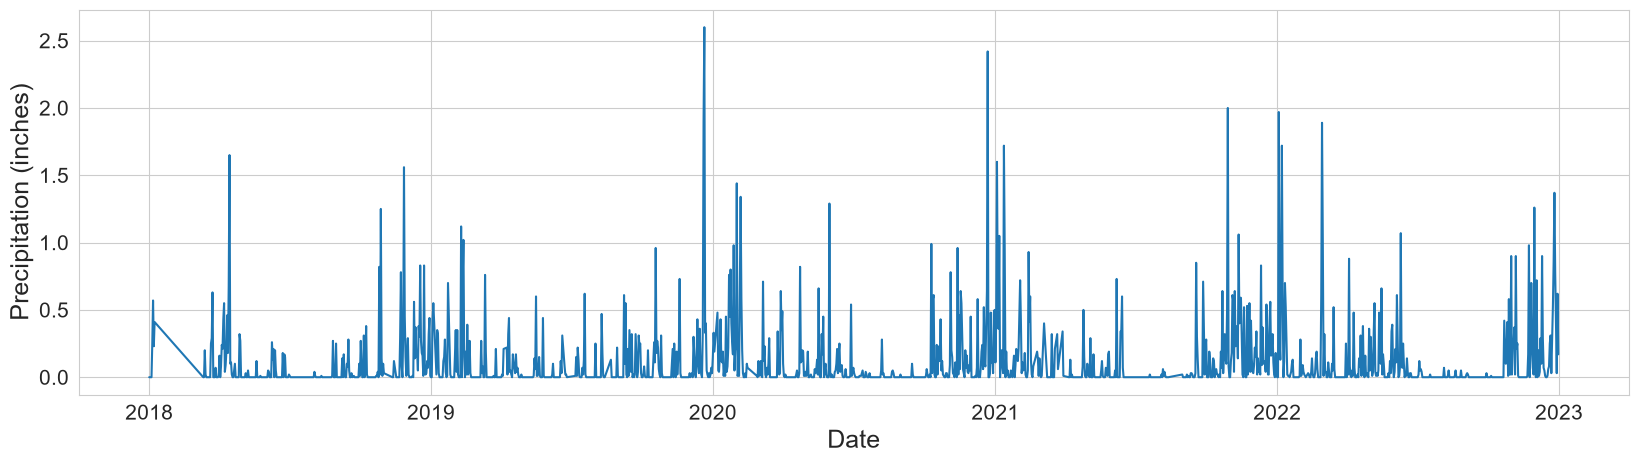

In [32]:
plt.figure(figsize = (20, 5))

sns.lineplot(data = df_seattle, x = 'DATE', y = 'PRCP')

plt.xlabel('Date', fontsize = 18)
plt.ylabel('Precipitation (inches)', fontsize = 18)

plt.tick_params(labelsize = 15)

plt.show()

### We can see some data is missing from the beginning of 2018

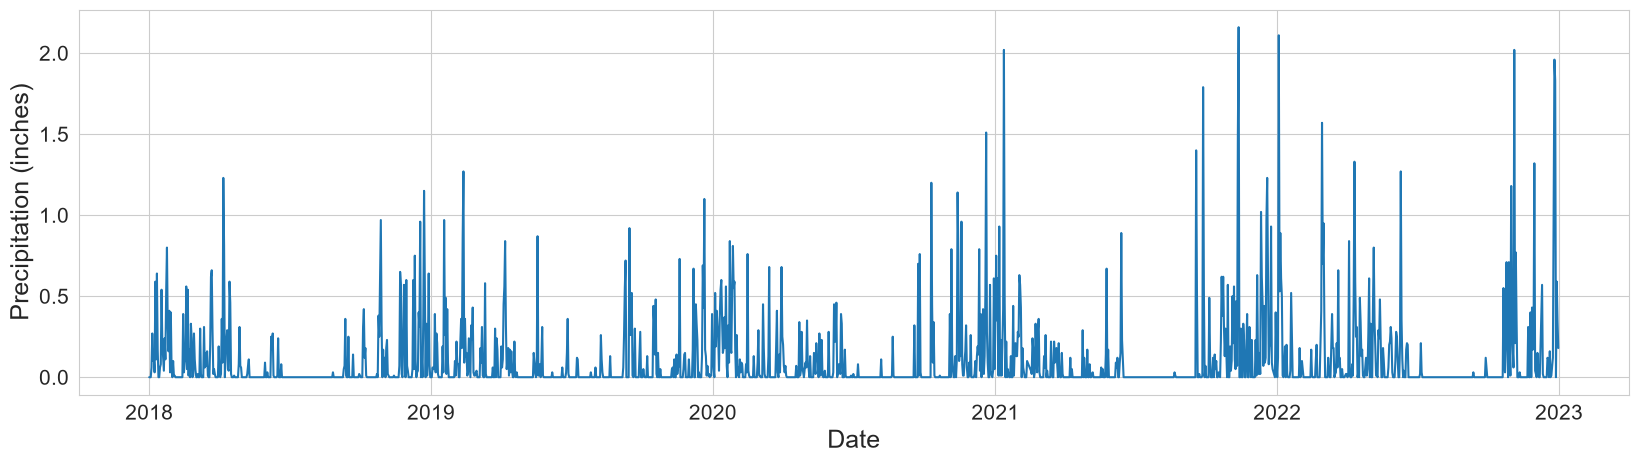

In [34]:
plt.figure(figsize = (20, 5))

sns.lineplot(data = df_portland, x = 'DATE', y = 'PRCP')

plt.xlabel('Date', fontsize = 18)
plt.ylabel('Precipitation (inches)', fontsize = 18)

plt.tick_params(labelsize = 15)

plt.show()

# Creating a merged dataframe with data from both cities

# Takes date and prcp columns only on key 'date'

In [40]:
df = df_portland[['DATE', 'PRCP']].merge(df_seattle[['DATE', 'PRCP']], on = 'DATE', how = 'outer')

# new prcp columns have x and y suffix
df.head()

,DATE,PRCP_x,PRCP_y
0,2018-01-01,0.00,0.00
1,2018-01-02,0.00,0.00
2,2018-01-03,0.00,0.00
3,2018-01-04,0.06,0.00
4,2018-01-05,0.27,0.25


### Put prcp into one column, separated by which city

In [41]:
df = pd.melt(df, id_vars = 'DATE', var_name = 'City', value_name = 'Precipitation')

df.head()

,DATE,City,Precipitation
0,2018-01-01,PRCP_x,0.00
1,2018-01-02,PRCP_x,0.00
2,2018-01-03,PRCP_x,0.00
3,2018-01-04,PRCP_x,0.06
4,2018-01-05,PRCP_x,0.27


### Fix city names

In [47]:
df.loc[df['City'] == 'PRCP_x', 'City'] = 'PDX'
df.loc[df['City'] == 'PRCP_y', 'City'] = 'SEA'

In [48]:
df.head()

,DATE,City,Precipitation
0,2018-01-01,PDX,0.00
1,2018-01-02,PDX,0.00
2,2018-01-03,PDX,0.00
3,2018-01-04,PDX,0.06
4,2018-01-05,PDX,0.27


In [49]:
df.tail()

,DATE,City,Precipitation
3647,2022-12-27,SEA,0.78
3648,2022-12-28,SEA,0.40
3649,2022-12-29,SEA,0.03
3650,2022-12-30,SEA,0.62
3651,2022-12-31,SEA,0.17


### Rename columns in all lowercase for ease of typing

In [51]:
df = df.rename(columns = {'DATE': 'date', 'City': 'city', 'Precipitation': 'precip'})

In [52]:
df.head()

,date,city,precip
0,2018-01-01,PDX,0.00
1,2018-01-02,PDX,0.00
2,2018-01-03,PDX,0.00
3,2018-01-04,PDX,0.06
4,2018-01-05,PDX,0.27


## Identify and fill in missing values

### Calculate null values

In [53]:
df.isna().sum()

date        0
city        0
precip    199
dtype: int64

In [54]:
#null values for seattle
df.loc[df['city'] == 'SEA', 'precip'].isna().sum()

np.int64(190)

In [55]:
#null values for portland
df.loc[df['city'] == 'PDX', 'precip'].isna().sum()

np.int64(9)

### The Seattle data is missing 190 values, where as the Portland data is only missing 9

### Check for missing dates

In [56]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3652 entries, 0 to 3651
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    3652 non-null   datetime64[us]
 1   city    3652 non-null   str           
 2   precip  3453 non-null   float64       
dtypes: datetime64[us](1), float64(1), str(1)
memory usage: 96.4 KB


In [58]:
# total days in these 5 years
print(5 * 365 + 1)
# date values we have divided between each city
print(3652 / 2)

1826
1826.0


### All of the dates with corresponding city labels are accounted for, and we can see those missing values for precip 

### There are multiple strategies for filling in missing data
### In this case, they will be filed in with the average (mean) precip for that day across all years with available data

### Create a new column to label the day of the year

In [59]:
df['day_of_year'] = pd.DatetimeIndex(df['date']).day_of_year

In [60]:
df.head()

,date,city,precip,day_of_year
0,2018-01-01,PDX,0.00,1
1,2018-01-02,PDX,0.00,2
2,2018-01-03,PDX,0.00,3
3,2018-01-04,PDX,0.06,4
4,2018-01-05,PDX,0.27,5


### Find the mean for each day of the year in seattle and store in the array 'mean_day_precip'

In [63]:
mean_day_precip = df.loc[df['city'] == 'SEA',
    ['precip', 'day_of_year']
    ].groupby('day_of_year').mean()

### and plot that calculated mean

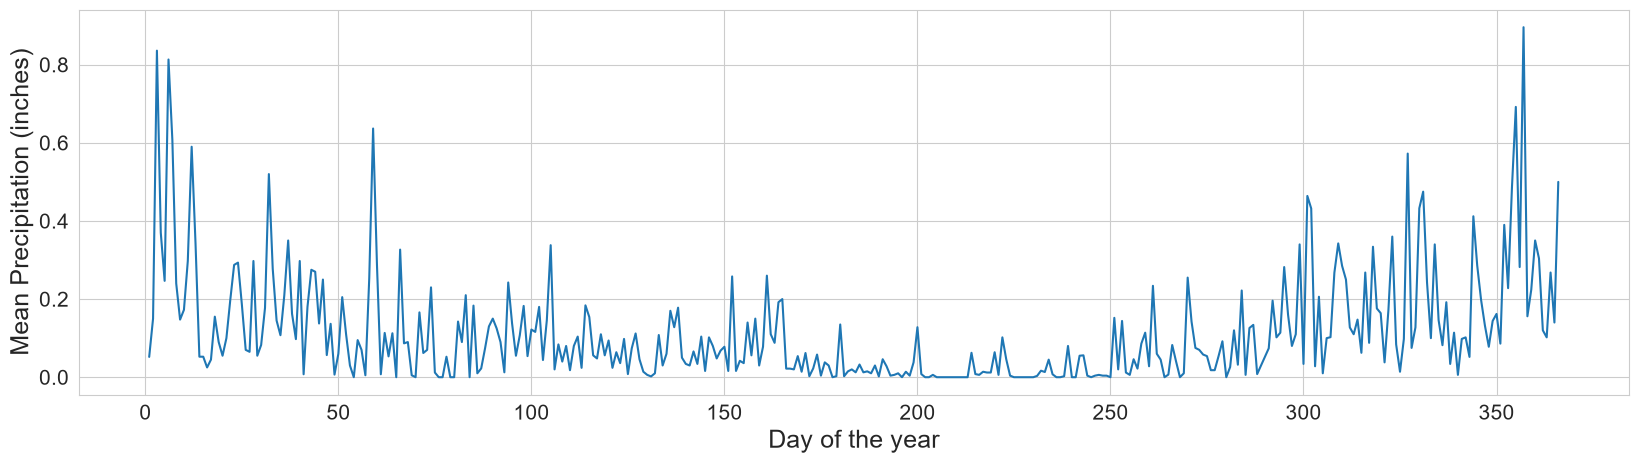

In [64]:
plt.figure(figsize = (20, 5))

sns.lineplot(data = mean_day_precip, x = 'day_of_year', y = 'precip')

plt.xlabel('Day of the year', fontsize = 18)
plt.ylabel('Mean Precipitation (inches)', fontsize = 18)

plt.tick_params(labelsize = 15)

plt.show()

### Find the index of each missing value

In [67]:
indices = np.where(df['precip'].isna() == True) [0]

### Replace that missing value with the mean using a for loop

In [69]:
for index in indices:
    df.loc[index, 'precip'] = mean_day_precip.loc[df.loc[index, 'day_of_year']].values [0]

### Check for missing values again to check success of for loop

In [71]:
df.isna().sum()

date           0
city           0
precip         0
day_of_year    0
dtype: int64

### Export this dataset to a new csv for future use

In [72]:
df.to_csv('clean_sea_pdx_weather.csv', encoding = 'utf-8-sig', index = False)